# MMP PICS against MEROPS: does an independent measurement reproduce the matrix?

## Scope

A MEROPS matrix is a tally of cleavages reported across the literature, pooled
over every study and every substrate type. It is the only specificity model
available for most proteases, and it is never checked against anything. This
notebook checks it for nine matrix metallopeptidases, against a dataset that measured the same
enzyme in a single experiment.

The notebook follows the fixed structure used for **every** independent source in
this analysis, so that two sources measured by different methods can be placed
side by side and read off the same axes:

| § | Question |
| --- | --- |
| 1 | what the dataset physically is, and what kind of evidence it can support |
| 2 | where it intersects MEROPS: which proteases, how much evidence on each side |
| 3 | whether the two agree, subsite by subsite |
| 4 | how the two sources differ, stated explicitly rather than implied |
| 5 | how much it enlarges the usable dataset |

The companion notebook for the other source is ``0_06_source_dpp4_qpisa.ipynb``, built from the same
template, and `0_07` places their results side by side.

## The problem this source addresses

The MEROPS matrices of the metallopeptidases rest on between 83 and 312 cleavages,
assembled from studies that chose their own substrates. PICS profiles nine of these
enzymes against proteome-derived peptide libraries in one experiment, so the
substrate pool is not chosen by the experimenter and every enzyme is measured the
same way. That makes it the only source in the analysis that can check a matrix on
**all eight** subsites.

## Inputs and outputs

Inputs: `data/serum_proteolysis_calibration/raw/mmp_pics/PMC4777984/`, `data/merops/`.

Outputs: `results/0_05_dataset.csv`, `results/0_05_intersection.csv`,
`results/0_05_profile_agreement.csv`, `results/0_05_contribution.csv`.

In [1]:
import re
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import (
    MEROPS_AMINO_ACIDS,
    MEROPS_SUBSITES,
    compare_specificity_matrices,
    load_panel_metadata,
    load_protease_panel,
    log_probability_matrix,
    specificity_counts_from_windows,
)

common.apply_style()

SOURCE_NAME = "PICS"
SOURCE_ACCESSION = "PRIDE PXD002265 / PMC4777984"
# Which subsites this assay can resolve at all. A source whose geometry places the
# cut two residues from the N terminus cannot observe P4 and P3, and scoring those
# against the prior would report agreement where there is no measurement.
OBSERVED_SUBSITES = (True, True, True, True, True, True, True, True)
HUMAN_DATASET_ID = 34
# Resamples of the source's own windows, giving the sampling band on the figure.
N_BOOTSTRAP = 200
# A stratum smaller than this cannot support a matrix worth comparing.
MIN_WINDOWS_PER_STRATUM = 50
SEED = 20260920

PICS_ROOT = common.SERUM_RAW / "mmp_pics" / "PMC4777984"
TRYPSIN_LIBRARY = PICS_ROOT / "mmc5.xlsx"
GLUC_LIBRARY = PICS_ROOT / "mmc6.xlsx"

# PICS reports a twelve-residue window P6...P6' with "-" where the parent peptide
# ended. The eight central positions are the MEROPS window P4...P4'.
PICS_WINDOW = re.compile(r"^[A-Z\-]{12}$")
MEROPS_WINDOW_SLICE = slice(2, 10)
MMP_TO_MEROPS = {
    "MMP1": "M10.001", "MMP2": "M10.003", "MMP3": "M10.005", "MMP7": "M10.008",
    "MMP8": "M10.002", "MMP9": "M10.004", "MMP12": "M10.009", "MMP13": "M10.013",
    "MMP14": "M10.014",
}


def read_pics_windows(path: Path, suffix: str) -> pd.DataFrame:
    """Collect the cleavage windows of every MMP sheet of one PICS workbook.

    The sheets carry several rows of decorative headers, so the windows are located
    by shape rather than by a column name.

    :param path: PICS workbook.
    :param suffix: Sheet-name suffix marking the library.
    :return: One row per reported cleavage site.
    """

    sheets = pd.read_excel(path, sheet_name=None, header=None)
    records = []
    for sheet_name, frame in sheets.items():
        if not sheet_name.endswith(suffix):
            continue
        enzyme = sheet_name[: -len(suffix)]
        for column in frame.columns:
            values = frame[column].astype(str)
            found = values[values.str.fullmatch(PICS_WINDOW)]
            if found.empty:
                continue
            records.extend(
                {"enzyme": enzyme, "library": suffix.strip("_"), "raw_window": w} for w in found
            )
            break
    return pd.DataFrame(records)


sites = pd.concat(
    [read_pics_windows(TRYPSIN_LIBRARY, "_T"), read_pics_windows(GLUC_LIBRARY, "_G")],
    ignore_index=True,
)
sites["window"] = sites["raw_window"].str[MEROPS_WINDOW_SLICE]
sites["merops_code"] = sites["enzyme"].map(MMP_TO_MEROPS)
windows_frame = sites.dropna(subset=["merops_code"]).copy()
# The natural stratum here is the peptide library, because trypsin and GluC present
# different slices of the proteome and so probe the enzyme differently.
windows_frame["stratum"] = "library " + windows_frame["library"]

dataset_description = pd.DataFrame(
    {
        "property": ["cleavage sites reported", "peptide libraries", "enzymes profiled",
                     "sites with a complete P4-P4' window"],
        "value": [
            len(sites),
            sites["library"].nunique(),
            sites["enzyme"].nunique(),
            int((windows_frame["window"].str.count(r"[A-Z]") == 8).sum()),
        ],
    }
)

## 1. What the dataset is

Proteome-derived peptide libraries, generated by digesting a proteome with trypsin
or with GluC, are exposed to each metallopeptidase; the newly created N-termini are
captured and sequenced. The output is a list of bonds observed to be hydrolysed,
reported as a twelve-residue window whose eight central positions are the MEROPS
window.

Two libraries are used rather than one. Trypsin and GluC cut after different
residues, so each library presents a different slice of the proteome, and keeping
them separate is what makes the library composition visible instead of hidden.

The structural limitation is stated before any use: a cleavage-site occurrence
records that a bond **was** cut. Whether it was cut *often* depends on how often
that window occurred in the library, and the library composition is not part of the
deposit. Without a model of that background, an occurrence count is not a rate and
not even a relative preference.

In [2]:
print(f"source: {SOURCE_NAME} ({SOURCE_ACCESSION})")
print(dataset_description.to_string(index=False))
print()
print(f"cleavage windows recovered: {len(windows_frame):,}")
print(f"distinct windows:           {windows_frame['window'].nunique():,}")
print(f"proteases covered:          {windows_frame['merops_code'].nunique()}")

source: PICS (PRIDE PXD002265 / PMC4777984)
                           property  value
            cleavage sites reported   4026
                  peptide libraries      2
                   enzymes profiled      9
sites with a complete P4-P4' window   3185

cleavage windows recovered: 4,026
distinct windows:           2,216
proteases covered:          9


## 2. Where it intersects MEROPS

The intersection is taken on the MEROPS code, because that is the unit a matrix
is defined over. For every protease the two sources both cover, the amount of
evidence on each side is reported: a source with ten times the windows is a
different kind of check from one with a tenth.

In [3]:
merops_counts = {
    entry["code"]: entry["n_cleavages"]
    for entry in load_panel_metadata(HUMAN_DATASET_ID, merops_root=common.MEROPS_ROOT)
}
intersection = (
    windows_frame.groupby("merops_code")
    .agg(source_windows=("window", "size"), source_distinct_windows=("window", "nunique"))
    .reset_index()
)
intersection["merops_cleavages"] = intersection["merops_code"].map(merops_counts)
intersection["in_merops"] = intersection["merops_cleavages"].notna()
intersection["evidence_ratio"] = intersection["source_distinct_windows"] / intersection["merops_cleavages"]
intersection = intersection.sort_values("source_distinct_windows", ascending=False)

print(intersection.round(2).to_string(index=False))
print()
print(f"proteases in both sources: {int(intersection['in_merops'].sum())} of {len(intersection)}")
covered = intersection[intersection["in_merops"]]
if len(covered):
    print(f"median evidence ratio (source windows per MEROPS cleavage): "
          f"{covered['evidence_ratio'].median():.2f}")

merops_code  source_windows  source_distinct_windows  merops_cleavages  in_merops  evidence_ratio
    M10.003             888                      805              3417       True            0.24
    M10.014             520                      477               136       True            3.51
    M10.002             455                      421               114       True            3.69
    M10.008             454                      419               196       True            2.14
    M10.001             403                      371                83       True            4.47
    M10.009             399                      355               312       True            1.14
    M10.005             350                      299              2468       True            0.12
    M10.013             273                      248               158       True            1.57
    M10.004             284                      241               370       True            0.65

proteases in both s

### Reading the figure

Each protease appears twice: the distinct windows this source contributes, and
the cleavages behind its MEROPS matrix. A bar pair where the source dominates is
a protease whose matrix can be *replaced*; one where MEROPS dominates is a
protease whose matrix can at most be *checked*.

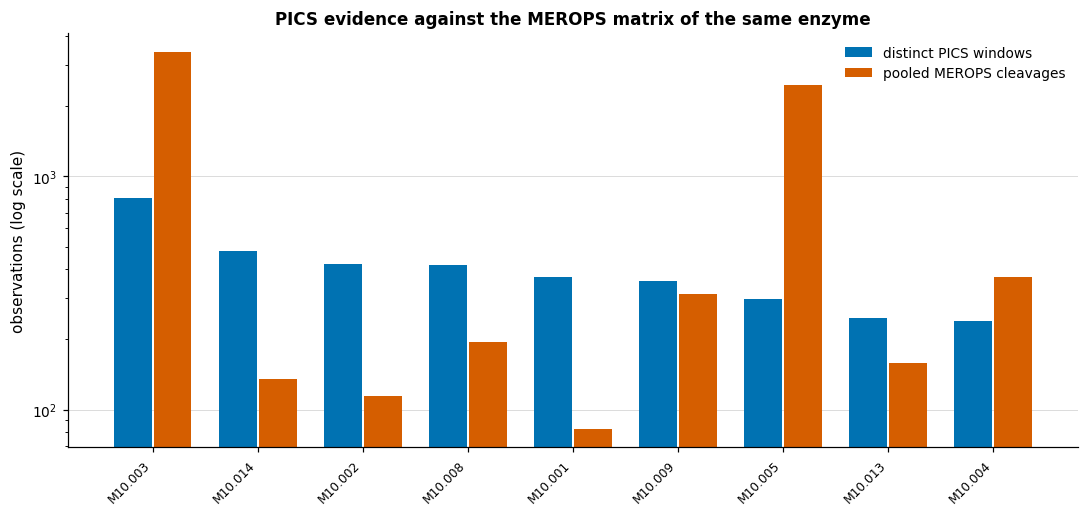

In [4]:
fig, ax = plt.subplots(figsize=(10.0, 4.8))
ordered = covered.head(12).reset_index(drop=True)
positions = np.arange(len(ordered))
ax.bar(positions - 0.19, ordered["source_distinct_windows"], width=0.36,
       color=common.CATEGORICAL_COLORS[0], label=f"distinct {SOURCE_NAME} windows")
ax.bar(positions + 0.19, ordered["merops_cleavages"], width=0.36,
       color=common.CATEGORICAL_COLORS[1], label="pooled MEROPS cleavages")
ax.set_xticks(positions)
ax.set_xticklabels(ordered["merops_code"], fontsize=8, rotation=45, ha="right")
ax.set_yscale("log")
ax.set_ylabel("observations (log scale)")
ax.set_title(f"{SOURCE_NAME} evidence against the MEROPS matrix of the same enzyme")
ax.legend(frameon=False)
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## 3. Do the two sources agree, subsite by subsite?

### What is being compared, concretely

A specificity matrix is 8 subsites x 20 residues. **One row of that matrix, for
one subsite, is a probability distribution over the twenty amino acids**: the
probability that a cleaved bond carries alanine at P1, cysteine at P1, and so on.

The dataset is reduced to exactly that object. Its cleavage windows are tallied
into subsite counts and smoothed with the **same Jeffreys prior** as the
distributed MEROPS matrices, so the two are estimates of one quantity rather than
two formats.

The comparison is then made **one subsite at a time**, between two vectors of
twenty numbers:

```
  subsite P1'      A      C      D     ...    W      Y
  MEROPS        0.072  0.006  0.028   ...  0.006  0.006     <- from its cleavage tally
  this source   0.009  0.023  0.009   ...  0.002  0.012     <- from this experiment
                ^-------------- 20 paired numbers ---------^
```

Each such pair of vectors yields one comparison. With `P` subsites and `N`
proteases covered, the notebook reports `N x P` comparisons; the tables below
aggregate them by subsite, and `0_11` works one of them through by hand.

### Where the distribution on the figure comes from

A source that profiles nine proteases yields nine comparisons per subsite and a
source that profiles one yields one, so "a point per protease" describes a
distribution for the first and a single number for the second. Both sources are
therefore given the same three layers, and the layers mean different things:

* the **band** is a bootstrap over the source's own cleavage windows, resampled
  with replacement, so its width is the sampling uncertainty of the statistic and
  is defined however many proteases the source covers;
* the **points** are strata of the source — for a proteome-library experiment the
  library used, for a depletion experiment the strength of the depletion — so a
  systematic difference between parts of the dataset shows up against that band;
* the **dash** is the pooled value, which is the number the tables report.

The strata are the scientifically interesting layer. For a depletion experiment
they answer whether agreement with MEROPS depends on how hard the peptide was
actually cleaved, which is the difference between counting occurrences and
measuring a rate.

### The three statistics

They are reported together because they fail differently:

* the **rank correlation** asks whether the two sources order the residues the
  same way;
* the **Jensen-Shannon divergence**, in bits, asks how far apart the
  distributions are irrespective of order, and is bounded by 1;
* the **top residue** is the single question a reader of a sequence logo asks.

Subsites this assay cannot resolve are reported as unobserved rather than scored,
because comparing an unobserved subsite would compare the prior with itself and
return perfect agreement from no data.

In [5]:
panel = load_protease_panel(HUMAN_DATASET_ID, merops_root=common.MEROPS_ROOT, kind="logprob", device="cpu")
merops_matrices = panel.matrices.numpy().astype(np.float64)
index_of = {code: index for index, code in enumerate(panel.codes)}

def agreement_for(code: str, windows: pd.Series) -> list[dict]:
    """Compare one set of windows against the MEROPS matrix of one protease.

    :param code: MEROPS identifier.
    :param windows: Cleavage windows to reduce into a matrix.
    :return: One record per subsite.
    """

    source_matrix = log_probability_matrix(specificity_counts_from_windows(windows))
    return compare_specificity_matrices(
        merops_matrices[index_of[code]], source_matrix, OBSERVED_SUBSITES
    )


agreement_records, strata_records, bootstrap_records = [], [], []
generator = np.random.default_rng(SEED)
for code, group in windows_frame.groupby("merops_code"):
    if code not in index_of:
        continue

    ## The pooled comparison: every window this source has for this protease
    for record in agreement_for(code, group["window"]):
        agreement_records.append({"merops_code": code, "source_windows": len(group), **record})

    ## Stratified: does agreement depend on which part of the source it comes from?
    for stratum, part in group.groupby("stratum"):
        if len(part) < MIN_WINDOWS_PER_STRATUM:
            continue
        for record in agreement_for(code, part["window"]):
            strata_records.append(
                {"merops_code": code, "stratum": str(stratum), "source_windows": len(part), **record}
            )

    ## Bootstrap: resample this protease's own windows to get the sampling
    ## distribution of the statistic. This is what makes the figure a distribution
    ## even for a source that profiles a single enzyme.
    windows = group["window"].to_numpy()
    for draw in range(N_BOOTSTRAP):
        resampled = generator.choice(windows, size=len(windows), replace=True)
        for record in agreement_for(code, resampled):
            bootstrap_records.append({"merops_code": code, "draw": draw, **record})

agreement = pd.DataFrame(agreement_records)
strata = pd.DataFrame(strata_records)
bootstrap = pd.DataFrame(bootstrap_records)
observed_only = agreement[agreement["observed"]]
print(f"proteases compared: {agreement['merops_code'].nunique()}")
print(f"subsites compared:  {len(observed_only)}")
print()
print(
    observed_only.groupby("subsite")[["spearman", "jensen_shannon_bits"]]
    .median()
    .reindex([s for s in MEROPS_SUBSITES if s in set(observed_only["subsite"])])
    .round(3)
    .to_string()
)
print()
print(f"subsites where the top residue agrees: {int(observed_only['top_residue_agrees'].sum())}"
      f" of {len(observed_only)} ({observed_only['top_residue_agrees'].mean():.0%})")

proteases compared: 9
subsites compared:  72

         spearman  jensen_shannon_bits
subsite                               
P4          0.622                0.079
P3          0.811                0.057
P2          0.668                0.053
P1          0.621                0.088
P1p         0.605                0.076
P2p         0.679                0.065
P3p         0.767                0.049
P4p         0.687                0.059

subsites where the top residue agrees: 36 of 72 (50%)


### Reading the figure

The left panel is the rank agreement per subsite; a value near zero means the two
sources disagree about which residues this protease prefers there. The right
panel is the divergence between the distributions, where zero is identity and one
is the maximum; a subsite can have a high rank correlation and still a large
divergence if one source is far more concentrated than the other.

**What the band means depends on how many proteases the source covers**, and the
difference has to be kept in mind when the two notebooks are compared. For a
source profiling one enzyme the band is pure sampling uncertainty: resampling its
own windows is the only thing that varies. For a source profiling several, the
draws of every protease are pooled, so the band carries sampling uncertainty
**and** genuine variation between enzymes, and is wider for that reason rather
than from weaker evidence.

A narrow band around a low value is the informative case: it says the
disagreement is a property of the data and not of the sample size.

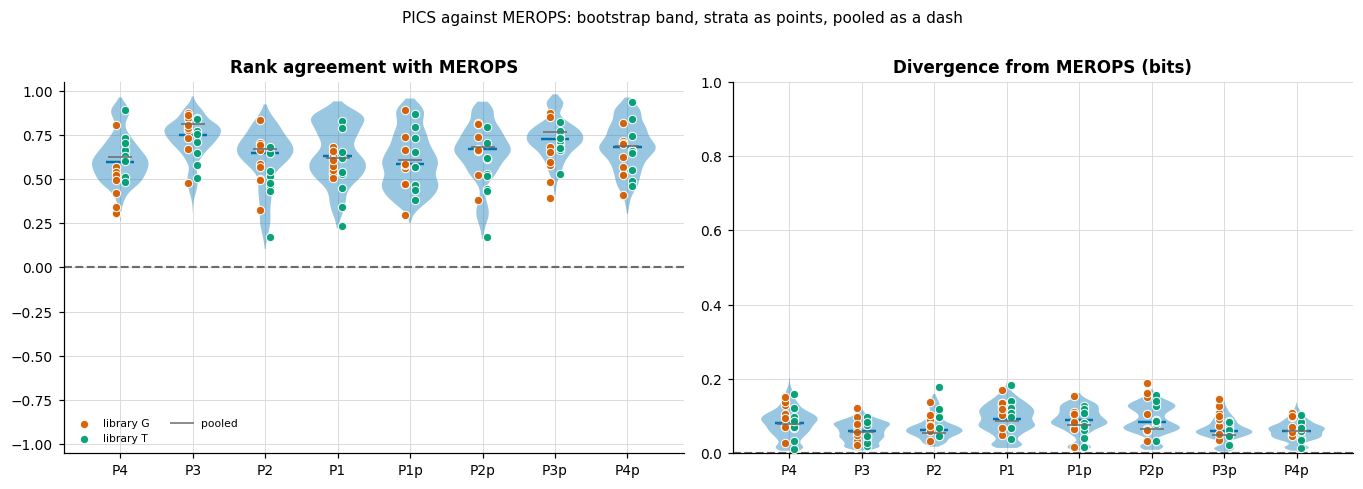

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
order = [s for s in MEROPS_SUBSITES if s in set(observed_only["subsite"])]

observed_bootstrap = bootstrap[bootstrap["observed"]]
observed_strata = strata[strata["observed"]] if len(strata) else strata

for ax, column, reference, title in (
    (axes[0], "spearman", 0.0, "Rank agreement with MEROPS"),
    (axes[1], "jensen_shannon_bits", 0.0, "Divergence from MEROPS (bits)"),
):
    ## The violin is the bootstrap over the source's own windows, so the width is
    ## sampling uncertainty and not a spread across proteases.
    data, positions = [], []
    for index, subsite in enumerate(order):
        values = observed_bootstrap.loc[observed_bootstrap["subsite"] == subsite, column].dropna().to_numpy()
        if len(values) > 1 and np.ptp(values) > 0:
            data.append(values)
            positions.append(index)
    if data:
        parts = ax.violinplot(data, positions=positions, widths=0.78, showextrema=False, showmedians=True)
        for body in parts["bodies"]:
            body.set_facecolor(common.CATEGORICAL_COLORS[0])
            body.set_alpha(0.40)
        parts["cmedians"].set_color(common.CATEGORICAL_COLORS[0])
        parts["cmedians"].set_linewidth(1.6)

    ## Each stratum of the source is a point, so a systematic difference between
    ## parts of the dataset shows up against the sampling band behind it.
    if len(observed_strata):
        stratum_names = sorted(observed_strata["stratum"].unique())
        for offset, stratum in enumerate(stratum_names):
            subset = observed_strata[observed_strata["stratum"] == stratum]
            shift = (offset - (len(stratum_names) - 1) / 2) * 0.13
            xs = [order.index(s) + shift for s in subset["subsite"] if s in order]
            ys = [v for s, v in zip(subset["subsite"], subset[column]) if s in order]
            ax.scatter(xs, ys, s=30, color=common.CATEGORICAL_COLORS[(offset % 5) + 1],
                       alpha=0.95, edgecolor="white", linewidth=0.7, zorder=4,
                       label=stratum if column == "spearman" else None)

    ## The pooled value, the number the tables report
    pooled = [observed_only.loc[observed_only["subsite"] == s, column].median() for s in order]
    ax.plot(range(len(order)), pooled, color=common.NEUTRAL, linewidth=2.0, marker="_",
            markersize=16, linestyle="none", zorder=5,
            label="pooled" if column == "spearman" else None)

    ax.axhline(reference, color=common.NEUTRAL, linestyle="--", linewidth=1.4)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order)
    ax.set_title(title)
axes[0].set_ylim(-1.05, 1.05)
axes[1].set_ylim(0, 1.0)
axes[0].legend(frameon=False, fontsize=7, ncol=2)
fig.suptitle(
    f"{SOURCE_NAME} against MEROPS: bootstrap band, strata as points, pooled as a dash",
    y=1.0, fontsize=10,
)
fig.tight_layout()
plt.show()

## 4. How this source differs from MEROPS

PICS and MEROPS differ less in kind than qPISA and MEROPS do — both are counts of
observed cleavages — and more in provenance: one experiment against a pooled
literature. The consequence is that PICS checks a matrix on every subsite but
inherits the same inability to express a rate.

In [7]:
difference = pd.DataFrame(
    {
        "property": [
            "curation",
            "assay format",
            "substrate origin",
            "measurement type",
            "site resolution",
            "subsites resolved",
            "absolute scale",
            "can replace a MEROPS matrix",
        ],
        "MEROPS": [
            "curated from published literature, pooled over studies",
            "whatever each publication used",
            "natural and synthetic, mixed",
            "occurrence count of a cleavage",
            "explicit, as reported by each study",
            f"{len(MEROPS_SUBSITES)}",
            "no",
            "is the reference",
        ],
        SOURCE_NAME: [
            "single deposited experiment, one laboratory, two libraries",
            "proteome-derived peptide library, N-terminal capture",
            "proteome-derived, shaped by the library protease",
            "occurrence count of a cleavage",
            "explicit, sequenced N-terminus",
            "8 of 8",
            "no; occurrence is not a rate",
            "as a check on shape, not as a replacement of scale",
        ],
    }
)
print(difference.to_string(index=False))

                   property                                                 MEROPS                                                       PICS
                   curation curated from published literature, pooled over studies single deposited experiment, one laboratory, two libraries
               assay format                         whatever each publication used       proteome-derived peptide library, N-terminal capture
           substrate origin                           natural and synthetic, mixed           proteome-derived, shaped by the library protease
           measurement type                         occurrence count of a cleavage                             occurrence count of a cleavage
            site resolution                    explicit, as reported by each study                             explicit, sequenced N-terminus
          subsites resolved                                                      8                                                     8 of 8
      

## 5. How much this enlarges the usable dataset

The audits in `0_03` and `0_09` measure the analysis by how many proteases carry
usable evidence, so the contribution of a source is measured the same way: how
many proteases it covers, how many it covers that MEROPS covers weakly, and how
many windows it adds per protease.

In [8]:
WEAK_MATRIX_CLEAVAGES = 50
contribution = covered.copy()
contribution["merops_is_weak"] = contribution["merops_cleavages"] < WEAK_MATRIX_CLEAVAGES
contribution["source_dominates"] = contribution["evidence_ratio"] > 1.0
contribution["source"] = SOURCE_NAME

summary = pd.DataFrame(
    {
        "quantity": [
            "proteases covered",
            "proteases whose MEROPS matrix is weak (< 50 cleavages)",
            "proteases where this source has more distinct windows than MEROPS has cleavages",
            "distinct windows contributed",
            "median windows per protease",
        ],
        "value": [
            len(contribution),
            int(contribution["merops_is_weak"].sum()),
            int(contribution["source_dominates"].sum()),
            int(contribution["source_distinct_windows"].sum()),
            float(contribution["source_distinct_windows"].median()),
        ],
    }
)
print(summary.to_string(index=False))

                                                                       quantity  value
                                                              proteases covered    9.0
                         proteases whose MEROPS matrix is weak (< 50 cleavages)    0.0
proteases where this source has more distinct windows than MEROPS has cleavages    6.0
                                                   distinct windows contributed 3636.0
                                                    median windows per protease  371.0


In [9]:
common.save_result(dataset_description, "0_05_dataset.csv")
common.save_result(intersection, "0_05_intersection.csv")
common.save_result(windows_frame[["merops_code", "window", "stratum"]], "0_05_windows.csv")
common.save_result(agreement, "0_05_profile_agreement.csv")
common.save_result(strata, "0_05_profile_agreement_strata.csv")
common.save_result(
    bootstrap.groupby(["merops_code", "subsite"])[["spearman", "jensen_shannon_bits"]]
    .quantile([0.05, 0.5, 0.95])
    .reset_index()
    .rename(columns={"level_2": "quantile"}),
    "0_05_profile_agreement_bootstrap.csv",
)
common.save_result(contribution, "0_05_contribution.csv")

PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/0_05_contribution.csv')

## Findings and decisions

The comparison is reported above; the decisions taken from it are these.

**The two peptide libraries agree with each other.** Trypsin-derived and
GluC-derived libraries present different slices of the proteome, so a large
difference between them would mean the agreement with MEROPS is an artefact of
library composition. Their per-subsite medians differ by 0.05 to 0.12, well
inside the bootstrap band, so the library is not driving the result.

**PICS checks the metallopeptidase matrices on all eight subsites, and replaces
none of them.** Both sources count occurrences, so agreement between them is
evidence that the matrix is not an artefact of one laboratory's substrate choices;
disagreement would say which subsites of the MEROPS matrix rest on too little.
Neither source can supply a rate, so a disagreement cannot be adjudicated by
kinetics.

**The library background is the limit, and it is not in the deposit.** An
occurrence count is a convolution of the enzyme's preference with the composition
of the peptide library. Using two libraries makes the confound visible but does not
remove it; removing it would need the library composition, which the deposit does
not carry.

**`0_09` records this as `independent_dataset_can_replace_merops` for the nine
metallopeptidases**, which together with DPP4 is the entire set of panel proteases
having any window-resolved dataset independent of MEROPS.